# Audio Classification Dataset Demo

This notebook demonstrates the milestone data loader for the spectrogram image dataset. Inputs are RGB spectrogram tensors and targets are integer class labels.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from audio_classification.data.dataset import SpectrogramDataset
from audio_classification.data.dataloader import get_data_loader

## Locate the Dataset

In [8]:
DATA_DIR = PROJECT_ROOT / "data" / "example_data"

print("Example data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

Example data directory: /Users/jurnee/Desktop/STEM EDUCATION/DSCI 410L/audio-classification-project/data/example_data
Exists: True


## Load One Sample

In [9]:
dataset = SpectrogramDataset(root_dir=DATA_DIR)

image, label = dataset[0]
class_name = dataset.idx_to_class[int(label)]

print("Number of training examples:", len(dataset))
print("Classes:", dataset.classes)
print("Input tensor shape:", tuple(image.shape))
print("Input dtype:", image.dtype)
print("Target label:", int(label))
print("Target class:", class_name)

Number of training examples: 12
Classes: ['Bass', 'Hi Hat', 'Kick', 'Pad', 'Snare', 'Vocal']
Input tensor shape: (3, 224, 224)
Input dtype: torch.float32
Target label: 0
Target class: Bass


## Load a Batch

In [10]:
loader = get_data_loader(root_dir=DATA_DIR, batch_size=5, shuffle=True)
images, labels = next(iter(loader))

print("Batch image shape:", tuple(images.shape))
print("Batch label shape:", tuple(labels.shape))
print("Batch labels:", labels.tolist())
print("Batch class names:", [dataset.idx_to_class[int(i)] for i in labels])

Batch image shape: (5, 3, 224, 224)
Batch label shape: (5,)
Batch labels: [4, 2, 1, 3, 4]
Batch class names: ['Snare', 'Kick', 'Hi Hat', 'Pad', 'Snare']


## Visualize Examples

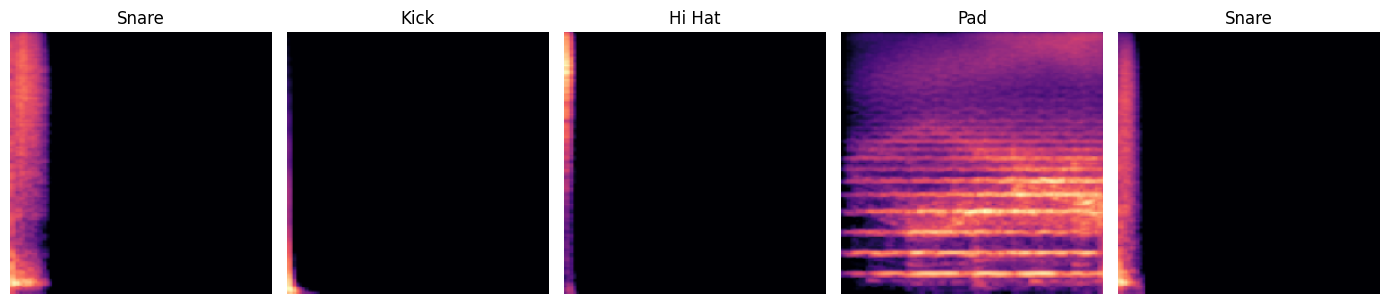

In [11]:
fig, axes = plt.subplots(1, min(5, len(images)), figsize=(14, 3))

for ax, img, lbl in zip(axes, images, labels):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(dataset.idx_to_class[int(lbl)])
    ax.axis("off")

plt.tight_layout()